<a href="https://colab.research.google.com/github/smartanilmali234-art/Anilmali/blob/main/Titanic_EDA_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 1 - Machine Learning Fundamentals

## Clean & Visualize Real-World Data

### Internship Task

**Dataset:** Titanic Dataset

**Objective**
- Clean missing values
- Detect outliers
- Visualize data
- Analyze important features affecting survival

Name:
GitHub Repository:
Date:

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.shape

(891, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Handling Missing Values

### Justification

The Titanic dataset contains missing values.

- **Age** is filled with the median because median is robust against outliers.
- **Embarked** is filled using the most frequent value (mode).
- **Cabin** has too many missing values, so it is removed because most of its information is unavailable.

This approach keeps most of the data while reducing bias.

In [8]:
df["Age"].fillna(df["Age"].median(), inplace=True)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

df.drop(columns=["Cabin"], inplace=True)

df.isnull().sum()

/tmp/ipykernel_1405/1904094665.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
/tmp/ipykernel_1405/1904094665.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


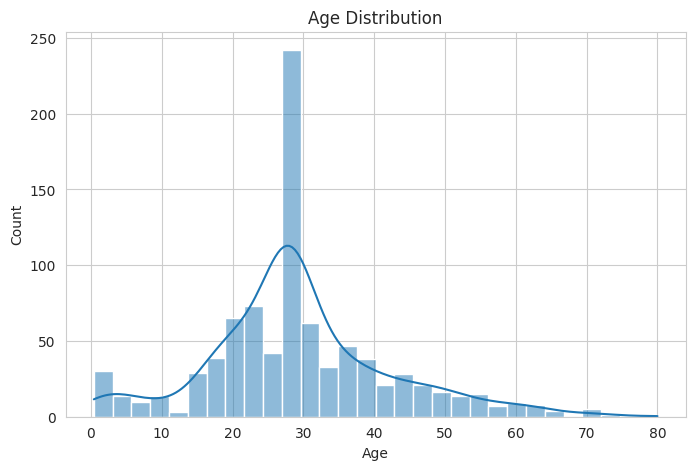

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=30, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

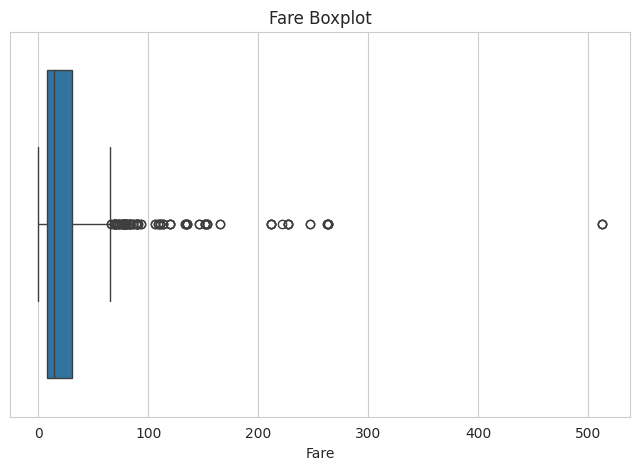

In [10]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Boxplot")

plt.show()

# Outlier Detection

The boxplot shows several outliers in the Fare column.

Some passengers paid extremely high ticket prices compared to the majority.

These values appear as points outside the whiskers of the boxplot.

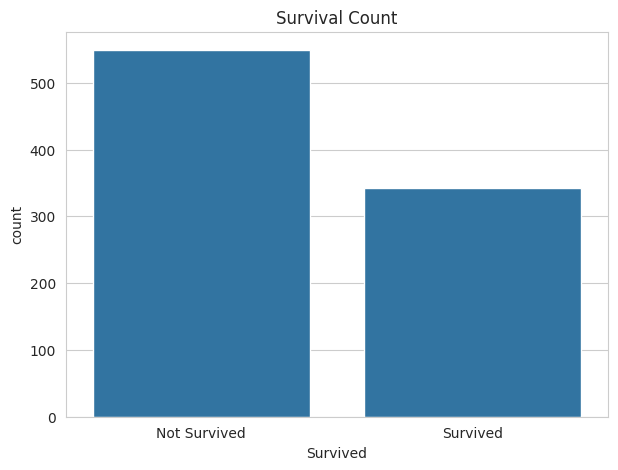

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")

plt.xticks([0,1],["Not Survived","Survived"])

plt.show()

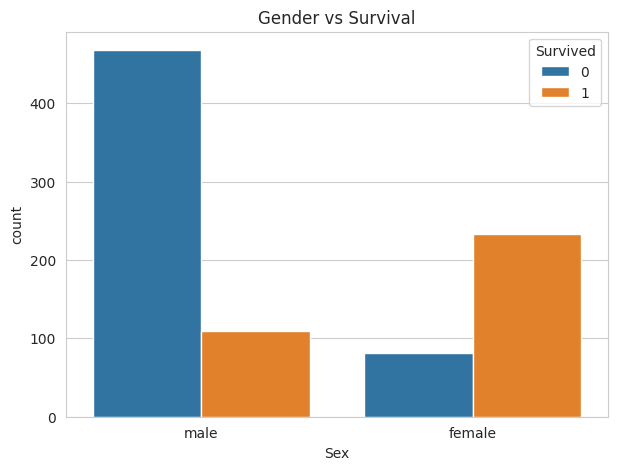

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Gender vs Survival")

plt.show()

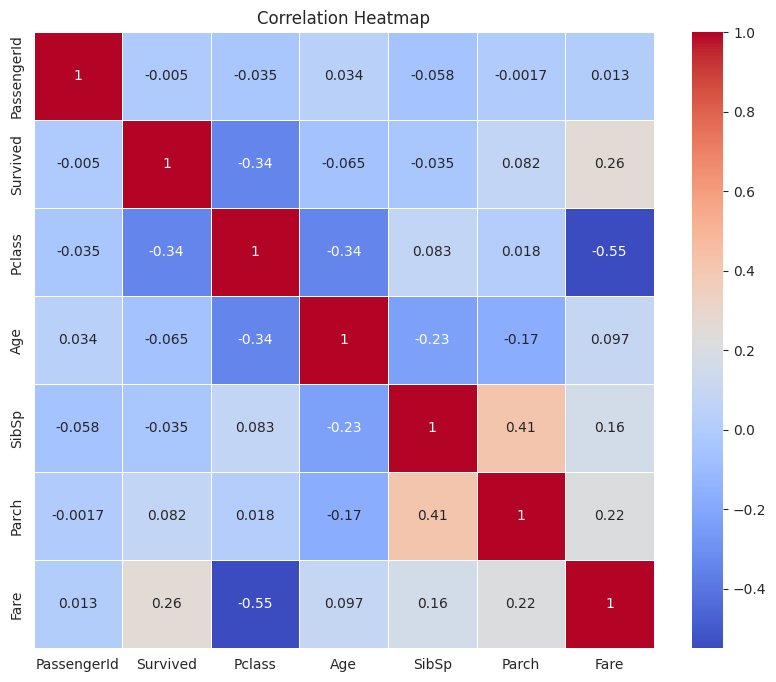

In [13]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

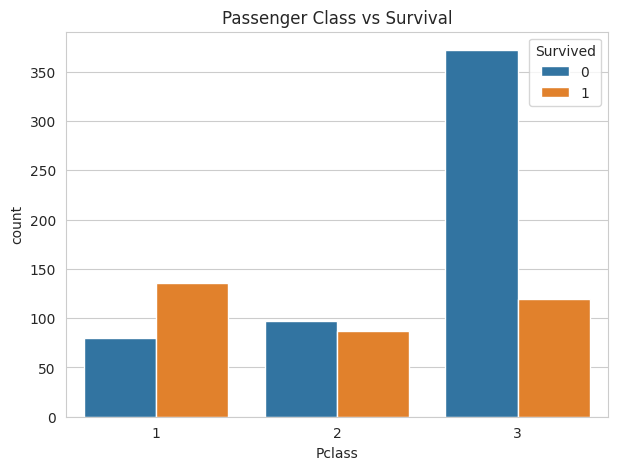

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Passenger Class vs Survival")

plt.show()

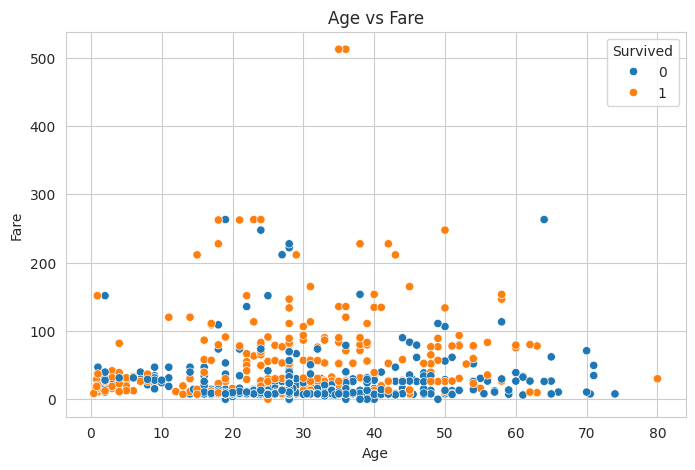

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Fare",
    hue="Survived",
    data=df
)

plt.title("Age vs Fare")

plt.show()

# Which Feature Most Affects Survival?

Among all features, **Sex** appears to have the strongest effect on survival.

The visualization shows that female passengers survived at a much higher rate than male passengers.

Passenger class (Pclass) also influenced survival because first-class passengers had better access to lifeboats and resources.

Therefore, Sex is the most significant feature, followed by Pclass.

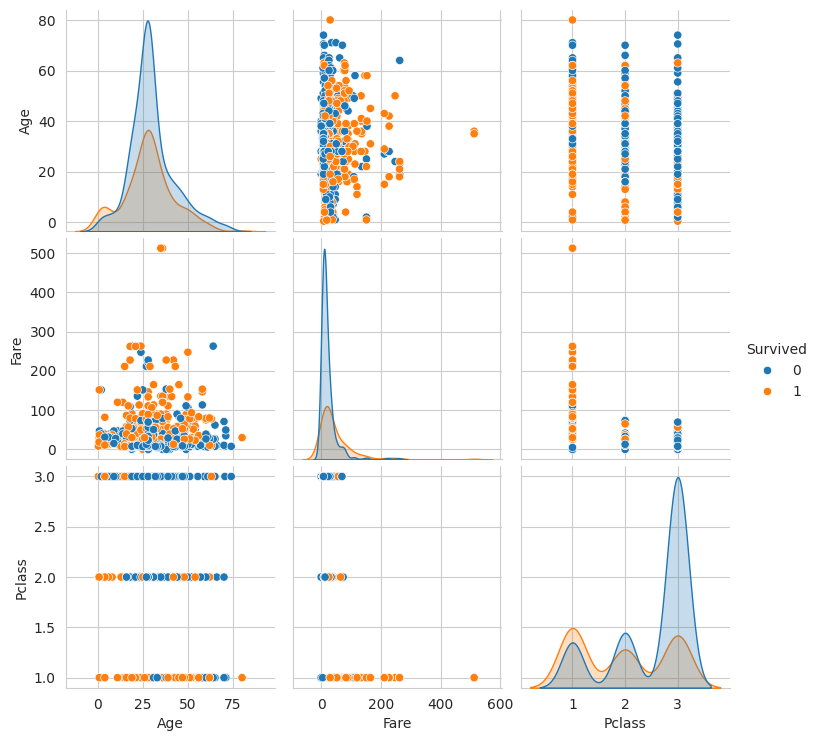

In [16]:
sns.pairplot(df[['Age','Fare','Pclass','Survived']],
             hue='Survived')

plt.show()

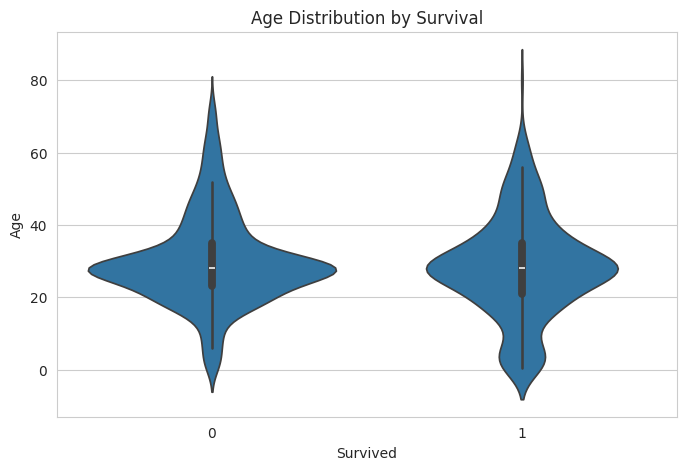

In [17]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Survived', y='Age', data=df)

plt.title("Age Distribution by Survival")
plt.show()

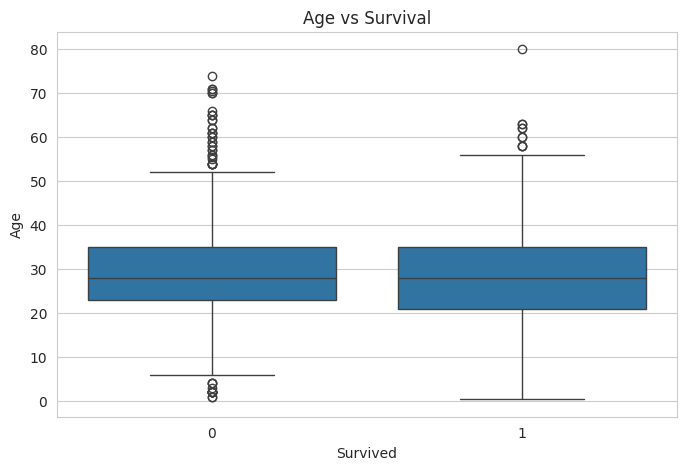

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Survived', y='Age', data=df)

plt.title("Age vs Survival")
plt.show()

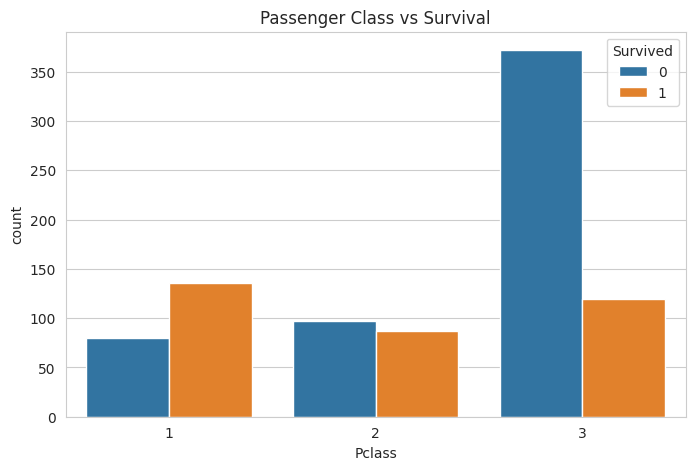

In [19]:
plt.figure(figsize=(8,5))
sns.countplot(x='Pclass', hue='Survived', data=df)

plt.title("Passenger Class vs Survival")
plt.show()

# Final Conclusion

In this project, I successfully cleaned and visualized the Titanic dataset by handling missing values, removing unnecessary data, and identifying outliers. I created multiple visualizations, including a histogram, boxplot, bar chart, and correlation heatmap, to better understand the dataset.

From the analysis, I observed that **Sex** and **Passenger Class (Pclass)** have the strongest influence on passenger survival. Female passengers and first-class passengers had significantly higher survival rates compared to others.

This project demonstrated that data cleaning and exploratory data analysis (EDA) are essential steps before building any machine learning model, as they help improve data quality and reveal important patterns and relationships.